In [1]:
import sys
import os
sys.path = [p for p in sys.path if "ParaView" not in p]
sys.path.append("/home/haseeb/Notebooks/Parameteric_DMD_cylinder_2D_modules")
import math
import torch as pt
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

mpl.rcParams['mathtext.fontset'] = 'cm'   # Computer Modern
import matplotlib.tri as mtri
from matplotlib.patches import Circle, Patch
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from flowtorch import DATASETS
from flowtorch.data import FOAMDataloader, mask_box
from flowtorch.analysis import DMD
from ezyrb import POD, Database, RBF, GPR, Linear
import seaborn as sns
from sklearn.utils.extmath import randomized_svd
from scipy.interpolate import griddata

from Flowtorch_DMD_cylinder_2D_modules import load_snapshots, preprocess_snapshots



from pathlib import Path
import re
# For High Quality Visuals
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 160  # crisp visuals

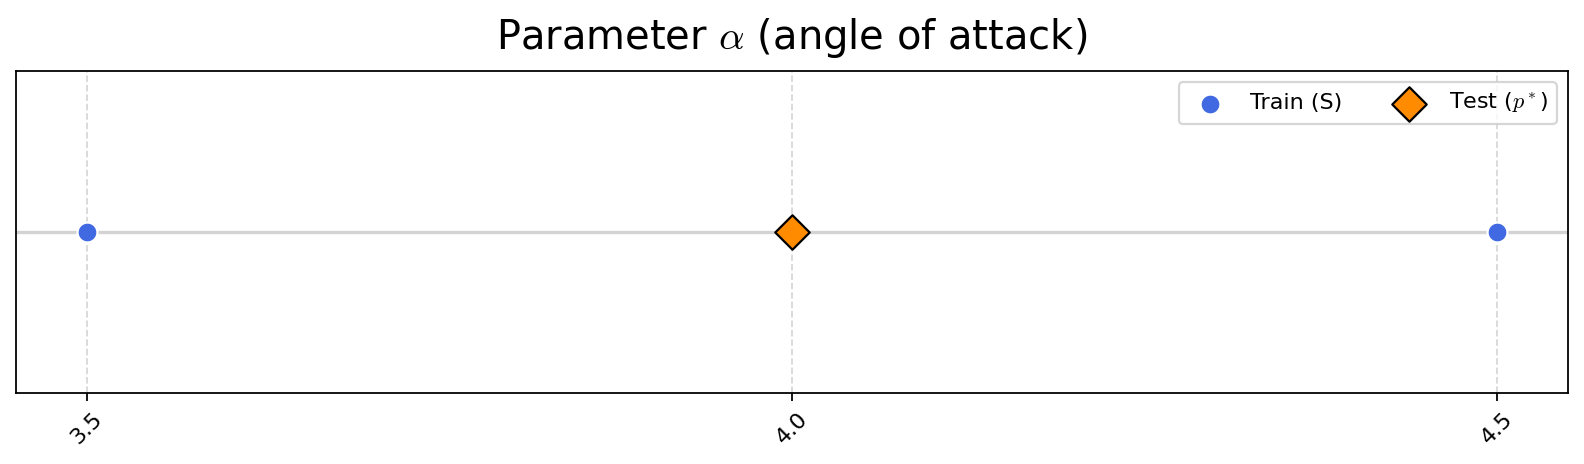

In [2]:

# Parameter set: angles of attack (deg)
alpha_list = np.array([ 3.5, 4.5])   # training
alpha_test = 4.0                                     # test

# Reference data from the OpenFOAM case
U_ref = 242.16629          # m/s
c_ref = 1.0                # m
rho_inf = 0.957837
mu = 7.7319e-5
nu = mu / rho_inf
Re = U_ref * c_ref / nu

U_ref_dict = {alpha: U_ref for alpha in alpha_list}
U_ref_test = U_ref

# Visualization
fig, ax = plt.subplots(figsize=(10, 3))
plt.title('Parameter $\\alpha$ (angle of attack)', fontsize=18, pad=10)

ax.scatter(alpha_list, np.zeros_like(alpha_list),
           marker='o', s=80, color='royalblue', edgecolor='white',
           label='Train (S)', zorder=3)

ax.scatter(alpha_test, 0,
           marker='D', s=120, color='darkorange', edgecolor='black',
           label='Test ($p^*$)', zorder=4)

plt.xticks(np.append(alpha_list, alpha_test), rotation=45, fontsize=10)
plt.yticks([])
ax.axhline(0, color='lightgray', linewidth=1.5, zorder=1)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend(ncols=2, frameon=True, fontsize=10)
plt.tight_layout()
plt.show()


In [3]:
import os
from Flowtorch_DMD_cylinder_2D_modules.loader_buffet import (
    load_buffet_training_snapshots,
    load_buffet_test_snapshots
)
from Flowtorch_DMD_cylinder_2D_modules.buffet_utils import (
    interpolate_uniform,
    load_force_coeffs
)

# Base folder containing buffet simulations
base_path = os.path.expanduser("~/OpenFOAM/buffet")

# Time window for training
training_window = (0.6, 1)

# Sampling step
sampling_step = 1

# Fields to load
fields = ("U", "cl")

# Load TRAINING data for all parameters μ ∈ P
train_data = load_buffet_training_snapshots(
    param_list=alpha_list,
    base_path=base_path,
    mask_box=mask_box,
    FOAMDataloader=FOAMDataloader,
    training_window=training_window,
    sampling_step=sampling_step,
    fields=fields,
    interpolate_cl=True,
    interpolate_uniform_fn=interpolate_uniform,
    load_force_coeffs_fn=load_force_coeffs
)

# Access training data
X_train_dict   = train_data.snapshots
cl_train_dict  = train_data.cl_train
coords         = train_data.coords
mask_indices   = train_data.mask_indices     
num_points     = train_data.num_points
train_times    = train_data.times[alpha_list[0]]

# Load TEST data for unseen parameter μ*
test_data = load_buffet_test_snapshots(
    param=alpha_test,
    base_path=base_path,
    FOAMDataloader=FOAMDataloader,
    train_times=train_times,
    mask_indices=mask_indices,               
    coords=coords,                           
    num_points=num_points,                   
    fields=fields,
    interpolate_cl=True,
    interpolate_uniform_fn=interpolate_uniform,
    load_force_coeffs_fn=load_force_coeffs
)

# Access test data
X_test          = test_data.snapshots
cl_test         = test_data.cl_test
coords_test     = test_data.coords
num_points_test = test_data.num_points


[2026-03-25 02:27:12] INFO     Loading precomputed cell centers and volumes from processor0/constant
[2026-03-25 02:27:12] INFO     Loading precomputed cell centers and volumes from processor1/constant
[2026-03-25 02:27:12] INFO     Loading precomputed cell centers and volumes from processor2/constant
[2026-03-25 02:27:12] INFO     Loading precomputed cell centers and volumes from processor3/constant
[2026-03-25 02:27:12] INFO     Loading precomputed cell centers and volumes from processor4/constant
[2026-03-25 02:27:12] INFO     Loading precomputed cell centers and volumes from processor5/constant
[2026-03-25 02:27:12] INFO     Loading precomputed cell centers and volumes from processor6/constant
[2026-03-25 02:27:12] INFO     Loading precomputed cell centers and volumes from processor7/constant
[2026-03-25 02:27:12] INFO     Loading precomputed cell centers and volumes from processor8/constant
[2026-03-25 02:27:12] INFO     Loading precomputed cell centers and volumes from processor9

Loaded training snapshots for α=3.5° (147606, 201)
Loaded training snapshots for α=4.5° (147606, 201)
Loaded test snapshots for α=4.0° (147606, 201)


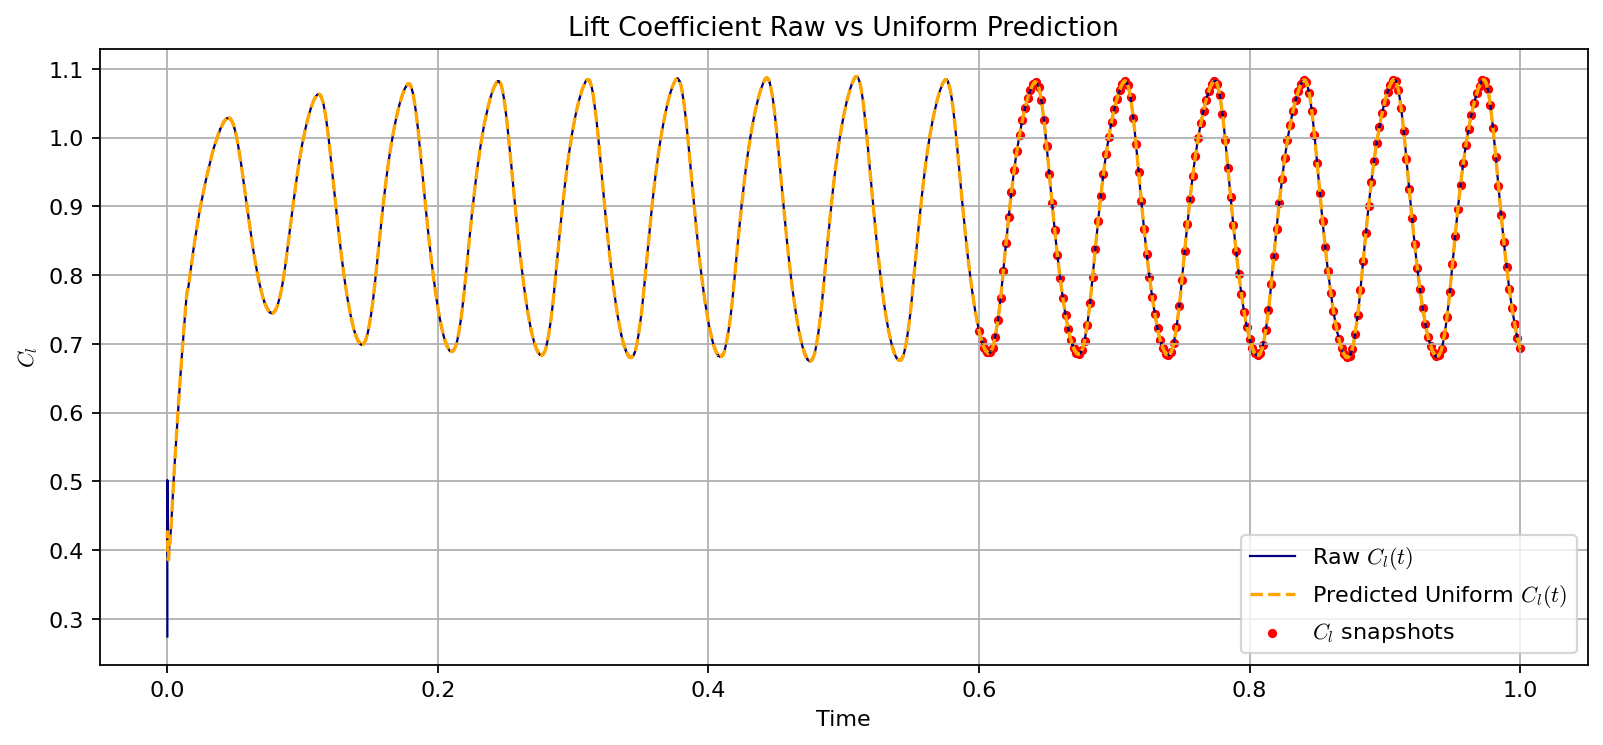

In [4]:
# Extract Cl time histories from loader
t_cl_raw, cl_raw   = train_data.cl_raw
t_cl_uni, cl_uni   = train_data.cl_uniform

# CFD snapshot times for the chosen alpha
train_times = train_data.times[alpha_list[0]]

plt.figure(figsize=(12,5))

# Raw Cl(t) from coefficient.dat
plt.plot(t_cl_raw, cl_raw, lw=1.0, color='navy', label="Raw $C_l(t)$")

# Uniform Cl(t) after interpolation — now dashed
plt.plot(t_cl_uni, cl_uni, lw=1.5, color='orange', linestyle='--',
         label="Predicted Uniform $C_l(t)$")

# Cl(t) sampled at CFD snapshot times (training window)
cl_snap = np.interp(train_times, t_cl_uni, cl_uni)
plt.scatter(train_times, cl_snap, color='red', s=10,
            label="$C_l$ snapshots")

plt.title("Lift Coefficient Raw vs Uniform Prediction")
plt.xlabel("Time")
plt.ylabel("$C_l$")
plt.grid(True)
plt.legend()
plt.show()



In [5]:

# RAW (non-uniform) time spacing
dt_raw = np.diff(t_cl_raw)

print(" RAW FORCE COEFF TIMESTEPS ")
print("min dt_raw :", dt_raw.min())
print("max dt_raw :", dt_raw.max())
print("mean dt_raw:", dt_raw.mean())
print("std dt_raw :", dt_raw.std())
print("raw uniform:", np.allclose(dt_raw, dt_raw[0]))

# UNIFORM (after interpolate_uniform)
dt_uni = np.diff(t_cl_uni)

print("\n UNIFORM FORCE COEFF TIMESTEPS")
print("min dt_uni :", dt_uni.min())
print("max dt_uni :", dt_uni.max())
print("mean dt_uni:", dt_uni.mean())
print("std dt_uni :", dt_uni.std())
print("uniform uniform:", np.allclose(dt_uni, dt_uni[0]))



 RAW FORCE COEFF TIMESTEPS 
min dt_raw : 4.0561499999999996e-08
max dt_raw : 1.0000000000287557e-06
mean dt_raw: 8.82028634565645e-07
std dt_raw : 2.3331152462363188e-07
raw uniform: False

 UNIFORM FORCE COEFF TIMESTEPS
min dt_uni : 9.999999999177334e-07
max dt_uni : 1.0000000000287557e-06
mean dt_uni: 1e-06
std dt_uni : 3.714218357842685e-17
uniform uniform: True


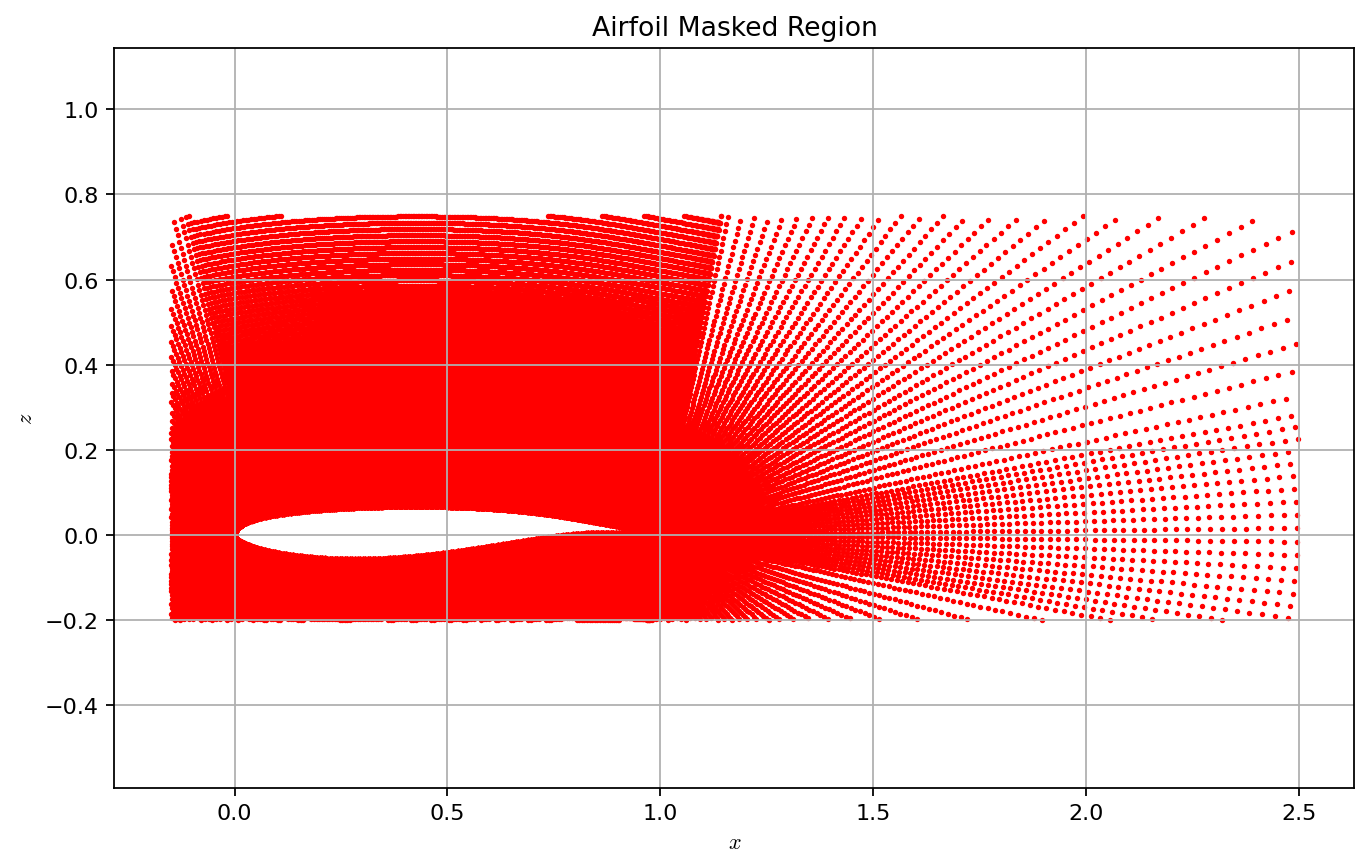

In [6]:
mask_coords = train_data.coords

plt.figure(figsize=(10, 6))
plt.scatter(mask_coords[:,0], mask_coords[:,1], s=2, color='red')

plt.xlabel("$x$")
plt.ylabel("$z$")
plt.title("Airfoil Masked Region")
plt.axis("equal")
plt.grid(True)
plt.show()


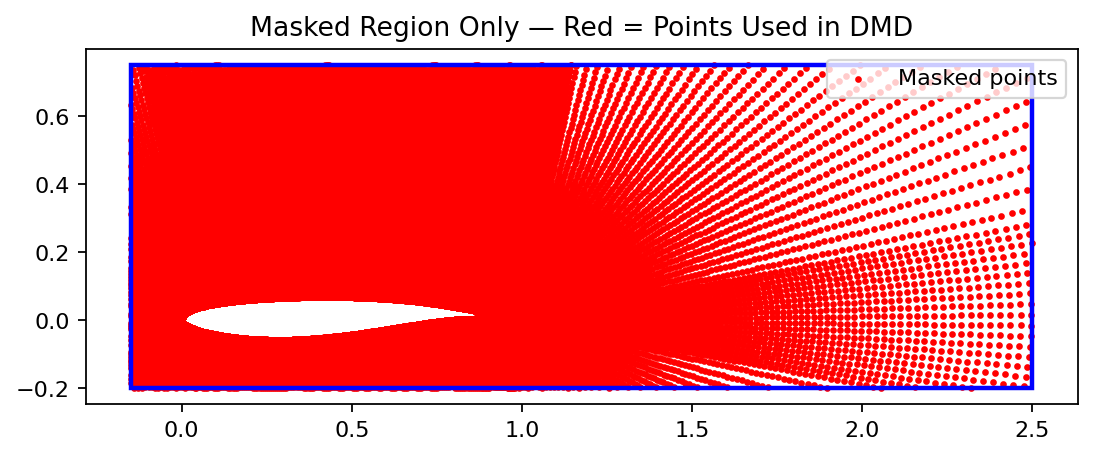

Total masked points: 73803


In [7]:

import matplotlib.patches as patches

# Masked points only
masked_pts = train_data.coords

# Bounding box used for masking
xmin, zmin = -0.15, -0.2
xmax, zmax =  2.5,  0.75

plt.figure(figsize=(8,4))

# Plot masked points
plt.scatter(masked_pts[:,0], masked_pts[:,1],
            s=4, c='red', label="Masked points")

# Draw the mask box
rect = patches.Rectangle((xmin, zmin),
                         xmax - xmin,
                         zmax - zmin,
                         linewidth=2, edgecolor='blue',
                         facecolor='none')
plt.gca().add_patch(rect)

plt.title("Masked Region Only — Red = Points Used in DMD")
plt.legend()
plt.gca().set_aspect('equal')
plt.show()

print("Total masked points:", len(masked_pts))



## Step 2. Train partitioned DMD

For each training parameter $\mu_j \in P = \{\mu_1, \mu_2, \dots, \mu_p\}$ i.e., Reynolds numbers $Re$, the fitted DMD operator is obtained via

$$
A^{(\mu_j)} \;\; \approx \;\; Y^{(\mu_j)} \, \big(X^{(\mu_j)})^{\dagger}
$$


where  
- $\mu_j$ : $j$‑th training parameter in the set $S$  
- $Re$ : Reynolds number corresponding to $\mu_j$  
- $X^{(\mu_j)} \in \mathbb{R}^{n_{\text{space}} \times (n_{\text{time}}-1)}$ : snapshot matrix at times $t_1, \dots, t_{n_{\text{time}}-1}$  
- $Y^{(\mu_j)} \in \mathbb{R}^{n_{\text{space}} \times (n_{\text{time}}-1)}$ : shifted snapshot matrix at times $t_2, \dots, t_{n_{\text{time}}}$  
- $A^{(\mu_j)}$ : DMD regression operator advancing the reduced state forward in time  



In [8]:
dmd_models = {}   # store DMD models per alpha

for alpha in alpha_list:

    # Extract X_train for this alpha
    X_train = X_train_dict[alpha]          # shape (3*num_points, Nt)

    # Extract Cl(t) for this alpha
    cl_train = cl_train_dict[alpha]        # shape (Nt,)
    cl_train_row = cl_train.reshape(1, -1) # shape (1, Nt)

    # Build augmented state: [Ux, Uz, p, Cl]
    X_aug = np.vstack([X_train, cl_train_row])

    # Convert to tensor
    X_p = pt.tensor(X_aug, dtype=pt.float64)

    # Time step
    dt = train_data.times[alpha][1] - train_data.times[alpha][0]

    # Fit DMD
    dmd = DMD(
        X_p,
        dt=dt,
        rank=150,
        tlsq=False,
        unitary=False,
        optimal=True,
        forward_backward=False
    )

    dmd_models[alpha] = dmd



[2026-03-25 02:27:37] INFO     Computing economy SVD via Gram matrix and eigendecomposition
[2026-03-25 02:27:38] INFO     Truncating SVD at index 150/200
[2026-03-25 02:27:39] INFO     Computing economy SVD via Gram matrix and eigendecomposition
[2026-03-25 02:27:39] INFO     Truncating SVD at index 150/200


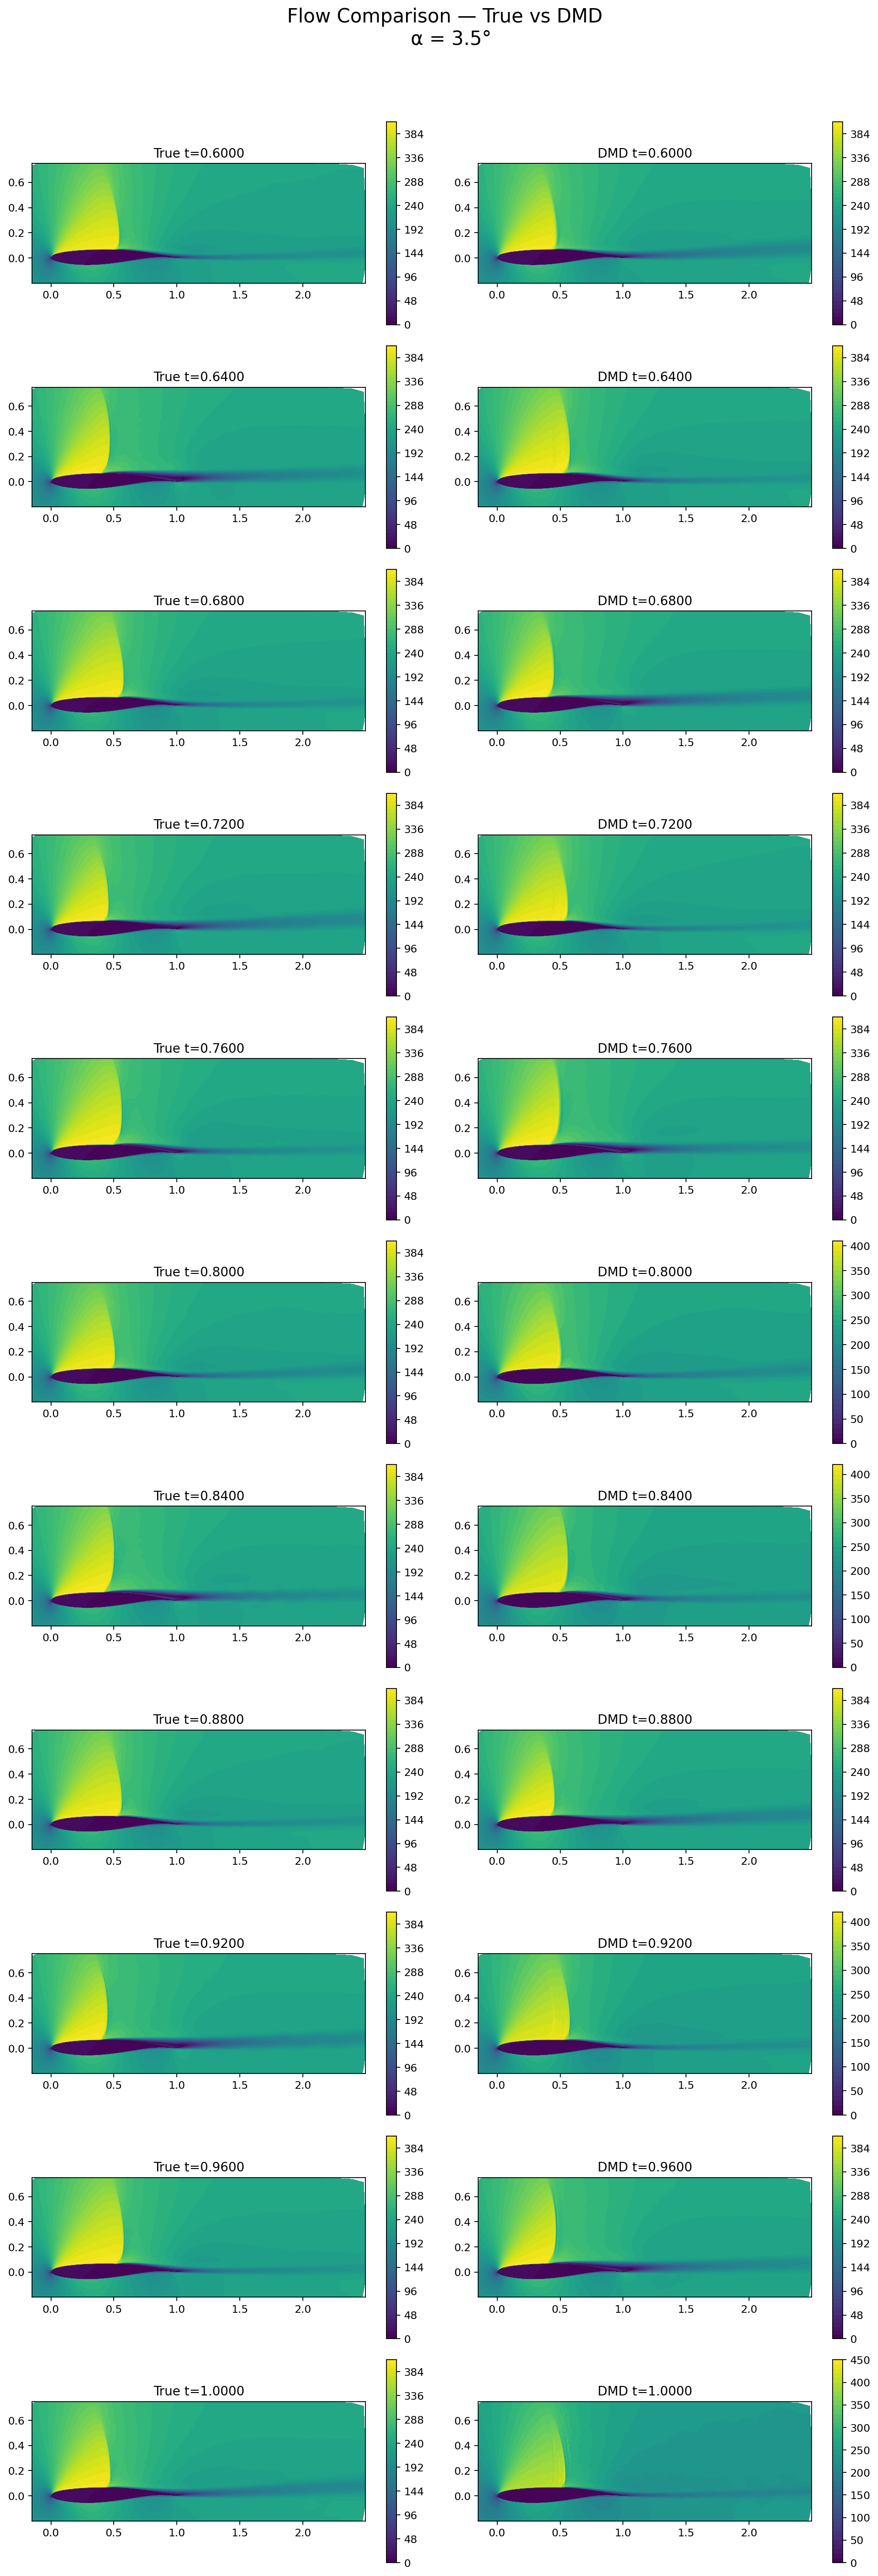

In [9]:

# Select which alpha to plot
alpha = alpha_list[0]   # change to 3.5 or 4.5 or loop later

# Extract data for this alpha
X_train = X_train_dict[alpha]
cl_train = cl_train_dict[alpha]
train_times = train_data.times[alpha]

# Masked coordinates
coords_masked = train_data.coords
num_points = coords_masked.shape[0]

# DMD reconstruction
X_rec_train = dmd_models[alpha].reconstruction.detach().cpu().numpy()

# Choose snapshot indices to visualize
indices = [0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200]   

# Create figure
n = len(indices)
fig, axes = plt.subplots(n, 2, figsize=(12, 3*n))

if n == 1:
    axes = axes.reshape(1, 2)

for row, i in enumerate(indices):

    # True and reconstructed states
    true_state = X_train[:, i]
    pred_state = X_rec_train[:, i]

    # Inline extraction of Ux, Uz
    Ux_true = true_state[0:num_points]
    Uz_true = true_state[num_points:2*num_points]

    Ux_pred = pred_state[0:num_points]
    Uz_pred = pred_state[num_points:2*num_points]

    # Velocity magnitude
    V_true = np.sqrt(Ux_true**2 + Uz_true**2)
    V_pred = np.sqrt(Ux_pred**2 + Uz_pred**2)

    # TRUE FIELD
    ax = axes[row, 0]
    tcf1 = ax.tricontourf(
        coords_masked[:,0],
        coords_masked[:,1],
        V_true,
        levels=50,
        cmap='viridis'
    )
    ax.set_title(f"True t={train_times[i]:.4f}")
    fig.colorbar(tcf1, ax=ax)
    ax.set_aspect('equal')

    # DMD FIELD
    ax = axes[row, 1]
    tcf2 = ax.tricontourf(
        coords_masked[:,0],
        coords_masked[:,1],
        V_pred,
        levels=50,
        cmap='viridis'
    )
    ax.set_title(f"DMD t={train_times[i]:.4f}")
    fig.colorbar(tcf2, ax=ax)
    ax.set_aspect('equal')
fig.suptitle(f"Flow Comparison — True vs DMD \n α = {alpha}°", fontsize=18, y=1.02)

plt.tight_layout()
plt.show()


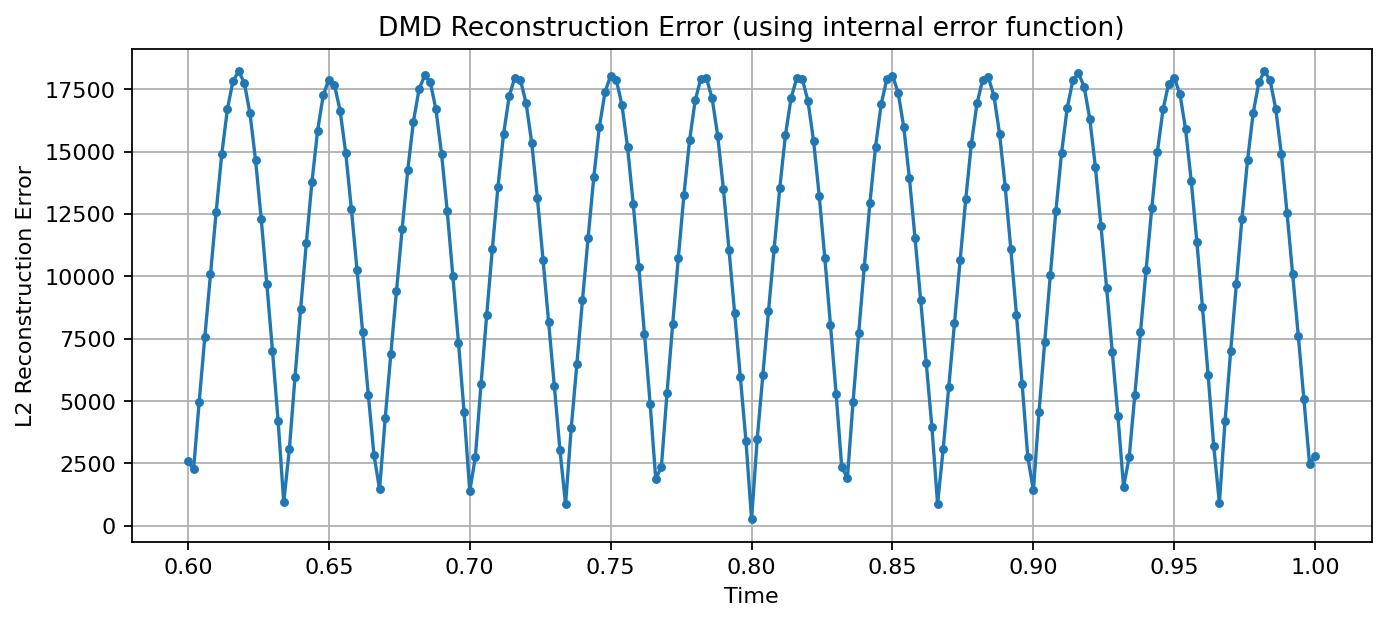

In [10]:


# Get internal DMD reconstruction error
err = dmd.reconstruction_error

# Normalize to a list of snapshots
if isinstance(err, list):
    err_list = err
else:
    # err is a big matrix of shape (n_features, n_snapshots)
    err_list = [err[:, i] for i in range(err.shape[1])]

# Convert to numpy
err_np = [e.detach().cpu().numpy() for e in err_list]

# Compute L2 error per snapshot
l2_err = [np.linalg.norm(e) for e in err_np]

# Plot
plt.figure(figsize=(10,4))
plt.plot(train_times, l2_err, '-o', markersize=3)
plt.xlabel("Time")
plt.ylabel("L2 Reconstruction Error")
plt.title("DMD Reconstruction Error (using internal error function)")
plt.grid(True)
plt.show()



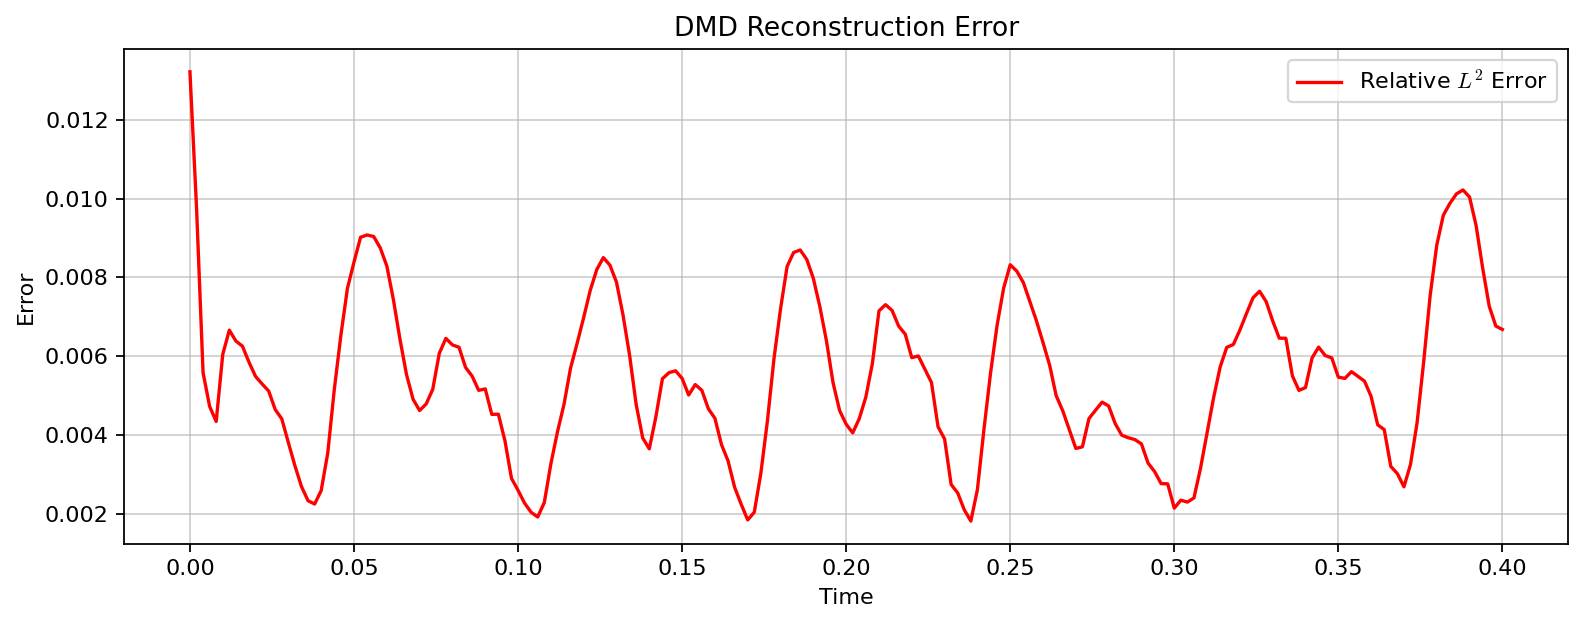

In [11]:

#  Extract true snapshots
X_true = X_p.detach().cpu().numpy()   # shape: (n_features, n_time)

#  Extract DMD modes & dynamics
modes = dmd.modes.detach().cpu().numpy()          # Φ
dynamics = dmd.dynamics.detach().cpu().numpy()    # time dynamics

#  Flip dynamics if needed (your convention)
dynamics_flipped = np.flip(dynamics, axis=1)

#  Manual DMD reconstruction
X_dmd = np.real(modes @ dynamics_flipped)   # shape: (n_features, n_time)

#  Build time vector
time_vec = np.array(train_times, dtype=float)
time_vec = time_vec - time_vec[0]   # start at zero

#  Compute reconstruction error
abs_error = np.linalg.norm(X_true - X_dmd, axis=0)
rel_error = abs_error / np.linalg.norm(X_true, axis=0)

#  Plot error
plt.figure(figsize=(10,4))
plt.plot(time_vec, rel_error, label="Relative $L^2$ Error", color="red")

plt.xlabel("Time")
plt.ylabel("Error")
plt.title("DMD Reconstruction Error")
plt.grid(True, alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


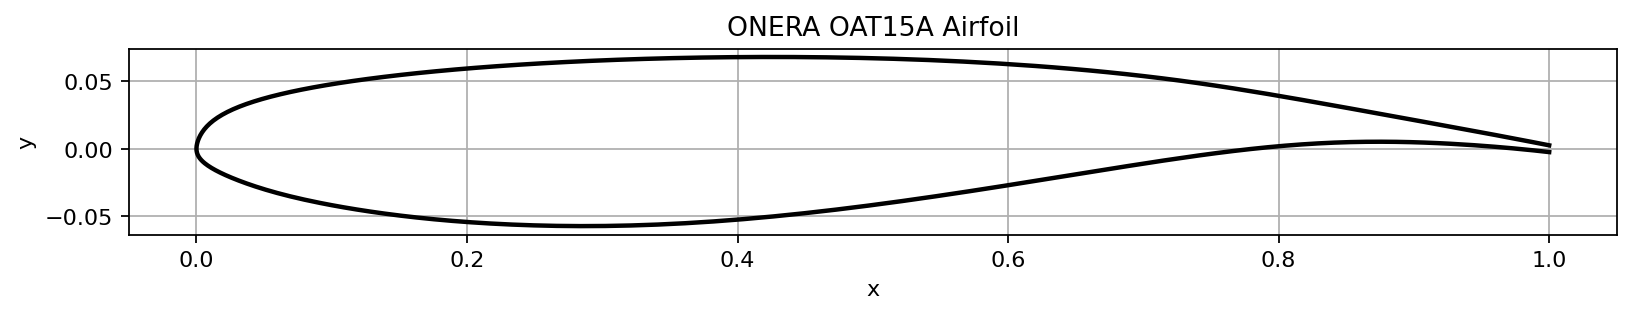

In [12]:

path = "/home/haseeb/OpenFOAM/buffet/ONERA-OAT15A-090524/ONERA-OAT15A/ONERA-OAT15A_coordiantes.dat"

coords = np.loadtxt(path)

x = coords[:, 0]
y = coords[:, 1]

plt.figure(figsize=(12,3))
plt.plot(x, y, 'k-', linewidth=2)
plt.gca().set_aspect('equal', 'box')
plt.title("ONERA OAT15A Airfoil")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()


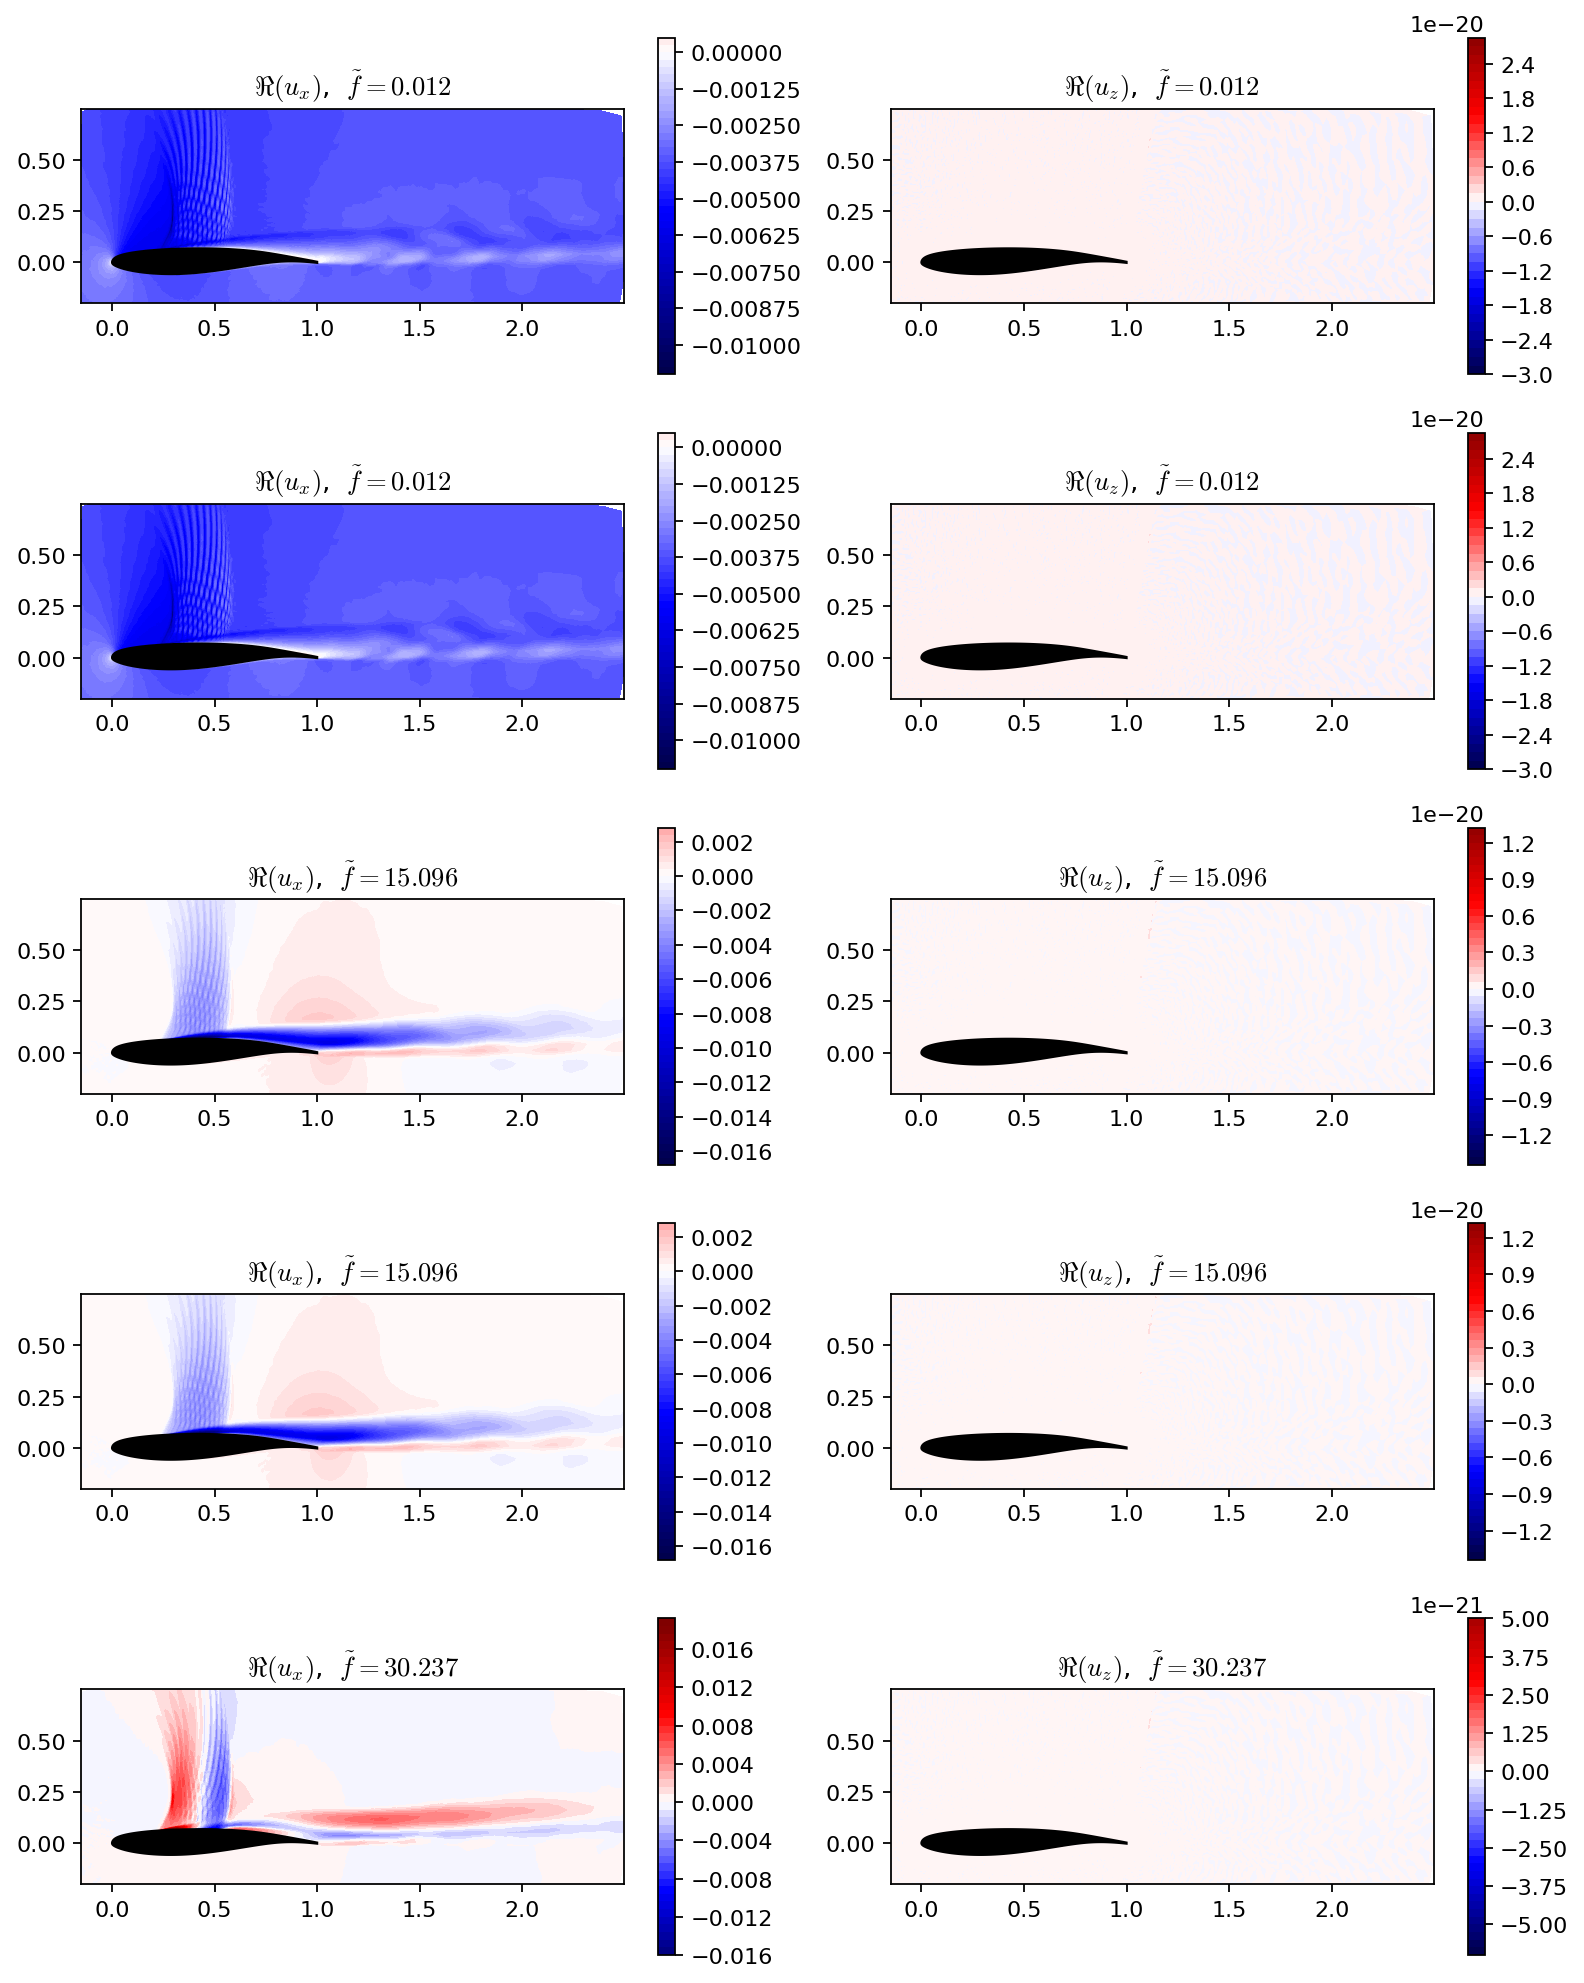

In [13]:
# Use masked coordinates
coords_fluid = coords_masked
num_fluid    = num_points

# Load airfoil outline
coords = np.loadtxt("/home/haseeb/OpenFOAM/buffet/ONERA-OAT15A-090524/ONERA-OAT15A/ONERA-OAT15A_coordiantes.dat")
xaf = coords[:, 0]
yaf = coords[:, 1]

# --- Correct: use integral contribution ranking ---
top5 = dmd.top_modes(n=5, integral=True)

freqs = dmd.frequency.detach().cpu().numpy()
modes = dmd.modes.detach().cpu().numpy()

fig, axes = plt.subplots(len(top5), 2, figsize=(10, 2.5*len(top5)))

for row, k in enumerate(top5):

    mode_k = modes[:, k]

    Ux = np.real(mode_k[0:num_fluid])
    Uz = np.real(mode_k[num_fluid:2*num_fluid])
    

    lim_u = np.max(np.abs(Ux))
    lim_w = np.max(np.abs(Uz))

    # Re(Ux)
    ax = axes[row, 0]
    tcf = ax.tricontourf(coords_fluid[:,0], coords_fluid[:,1],
                         Ux, levels=50, cmap='seismic',
                         vmin=-lim_u, vmax=lim_u)
    ax.fill(xaf, yaf, color='black')
    ax.set_aspect('equal')
    ax.set_title(rf"$\Re(u_x)$,  $\tilde f = {abs(freqs[k]):.3f}$")
    fig.colorbar(tcf, ax=ax)

    # Re(Uz)
    ax = axes[row, 1]
    tcf = ax.tricontourf(coords_fluid[:,0], coords_fluid[:,1],
                         Uz, levels=50, cmap='seismic',
                         vmin=-lim_w, vmax=lim_w)
    ax.fill(xaf, yaf, color='black')
    ax.set_aspect('equal')
    ax.set_title(rf"$\Re(u_z)$,  $\tilde f = {abs(freqs[k]):.3f}$")
    fig.colorbar(tcf, ax=ax)

plt.tight_layout()
plt.show()


In [14]:
# Print the Vandermonde matrix structure
pt.vander(pt.tensor([2.0]), N=5)


tensor([[16.,  8.,  4.,  2.,  1.]])